# Getting Skagit Data

In [1]:
import geopandas as gpd
import rioxarray
import numpy as np
import csv

import xarray as xr
import matplotlib.pyplot as plt
from shapely.geometry import mapping
from rasterio.mask import mask

In [2]:
# create UA SWE dataset
path_ua = '../Dataset/UA_Data/'
files_ua = path_ua + '4km_SWE_Depth*.nc'
ds_ua = xr.open_mfdataset(files_ua, engine="netcdf4", data_vars='all')

In [3]:
# clip data
skagit_boundary = gpd.read_file('../Dataset/ShapeFiles/SkagitBoundary.json')

poly = skagit_boundary.geometry.to_list()
ua_skagit_clipped = ds_ua.SWE.rio.set_spatial_dims(x_dim='lon', y_dim='lat', inplace=True)
ua_skagit_clipped = ua_skagit_clipped.rio.write_crs("epsg:4326", inplace=True)
ua_skagit_clipped = ua_skagit_clipped.rio.clip(poly, crs="epsg:4326")

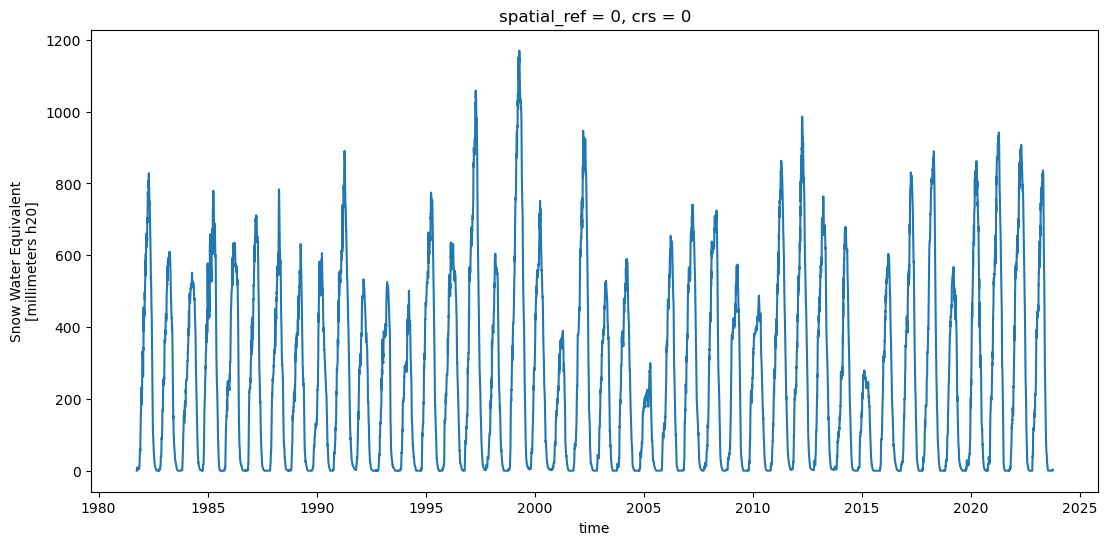

In [4]:
# plot mean
ua_skagit_clipped_mean = ua_skagit_clipped.mean(dim= ('lat', 'lon'))
ua_skagit_clipped_mean = ua_skagit_clipped_mean.assign_coords(
    year=ua_skagit_clipped_mean.time.dt.year)

plt.figure(figsize=(13, 6))
ua_skagit_clipped_mean.plot()

In [40]:
# read AR data
from pandas import to_datetime
import csv

AR_data = {}
AR_dates = []

with open('../Dataset/AR_Data/48N_event_data.csv') as f:
    reader = csv.reader(f)
    lines = list(reader)
    
    for line in lines:
        date = to_datetime(line[0], format='%Y%m%d%H')
        AR_dates.append(date)
        year = date.year
        scale = int(line[5])

        if year not in AR_data:
            AR_data[year] = {}
            
        AR_data[year][date] = scale
        #AR_data[year][scale] = AR_data[year].get(scale, 0) + 1

In [36]:
for i in range(0,10):
    print(AR_dates[i])

1959-10-10 23:00:00
1959-10-13 11:00:00
1959-10-21 23:00:00
1959-10-23 11:00:00
1959-11-11 08:00:00
1959-11-17 00:00:00
1959-11-19 21:00:00
1959-11-22 04:00:00
1959-12-10 23:00:00
1959-12-14 01:00:00


In [41]:
print(AR_data[1984])

{Timestamp('1984-01-01 22:00:00'): 1, Timestamp('1984-01-03 03:00:00'): 4, Timestamp('1984-01-22 05:00:00'): 1, Timestamp('1984-01-23 03:00:00'): 3, Timestamp('1984-01-26 13:00:00'): 1, Timestamp('1984-02-07 19:00:00'): 1, Timestamp('1984-02-09 00:00:00'): 1, Timestamp('1984-02-12 07:00:00'): 1, Timestamp('1984-02-19 09:00:00'): 2, Timestamp('1984-03-20 05:00:00'): 1, Timestamp('1984-04-13 22:00:00'): 2, Timestamp('1984-05-07 23:00:00'): 1, Timestamp('1984-05-18 15:00:00'): 2, Timestamp('1984-06-26 00:00:00'): 1, Timestamp('1984-06-27 13:00:00'): 2, Timestamp('1984-06-30 19:00:00'): 2, Timestamp('1984-07-03 23:00:00'): 1, Timestamp('1984-07-25 17:00:00'): 1, Timestamp('1984-08-15 20:00:00'): 1, Timestamp('1984-08-26 18:00:00'): 1, Timestamp('1984-09-04 09:00:00'): 1, Timestamp('1984-09-15 20:00:00'): 2, Timestamp('1984-10-03 18:00:00'): 1, Timestamp('1984-10-06 05:00:00'): 5, Timestamp('1984-10-09 08:00:00'): 3, Timestamp('1984-10-12 09:00:00'): 1, Timestamp('1984-10-24 12:00:00'): 2, 

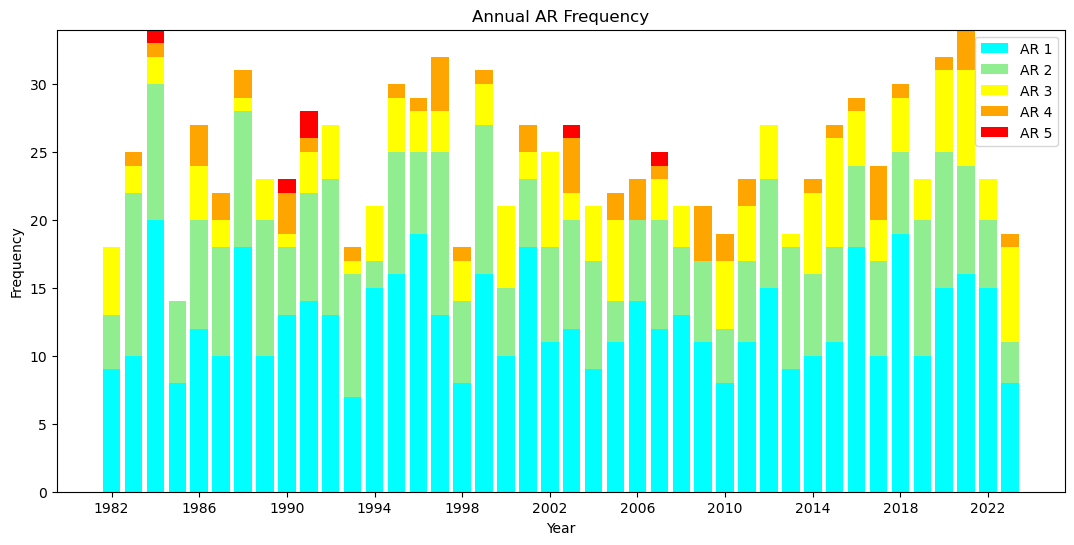

In [24]:
# plot annual frequency
years = np.array(sorted(AR_data.keys()))
# slice years to match SWE data
years = years[23:65]

ar1 = []
ar2 = []
ar3 = []
ar4 = []
ar5 = []

for year in years:
    data = AR_data[year]
    
    ar1.append(data.get(1, 0))
    ar2.append(data.get(2, 0))
    ar3.append(data.get(3, 0))
    ar4.append(data.get(4, 0))
    ar5.append(data.get(5, 0))

ar1 = np.array(ar1)
ar2 = np.array(ar2)
ar3 = np.array(ar3)
ar4 = np.array(ar4)
ar5 = np.array(ar5)

plt.figure(figsize=(13, 6))

plt.bar(years, ar1, color='cyan')
plt.bar(years, ar2, bottom=ar1, color='lightgreen')
plt.bar(years, ar3, bottom=ar1+ar2, color='yellow')
plt.bar(years, ar4, bottom=ar1+ar2+ar3, color='orange')
plt.bar(years, ar5, bottom=ar1+ar2+ar3+ar4, color='r')

plt.xlabel("Year")
plt.ylabel("Frequency")
plt.legend(["AR 1", "AR 2", "AR 3", "AR 4", "AR 5"])
plt.title("Annual AR Frequency")
plt.xticks(np.arange(years.min(), years.max() + 1, 4))
plt.show()

In [46]:
def filter_dates(scale):
    filtered_dates = []
    for date in AR_dates:
        year = date.year
        data = AR_data[year]

        freq = data[date]
        #freq = data.get(scale, 0)
        if freq == scale:
            filtered_dates.append(date)

    filtered_dates = [date for date in filtered_dates if 1982 <= date.year <= 2023]

    return filtered_dates

In [43]:
def graph_AR_Events(dates, SWE_events, scale, color):
    plt.figure(figsize=(13, 6))
    ua_skagit_clipped_mean.plot(label='SWANN 4km')
    
    plt.scatter(dates, SWE_events, facecolors='none', edgecolors=color, s=50, label=f"AR Events (scale {scale})")
    
    plt.legend()
    plt.xlabel("Years")
    plt.title("Skagit Basin")
    plt.show()

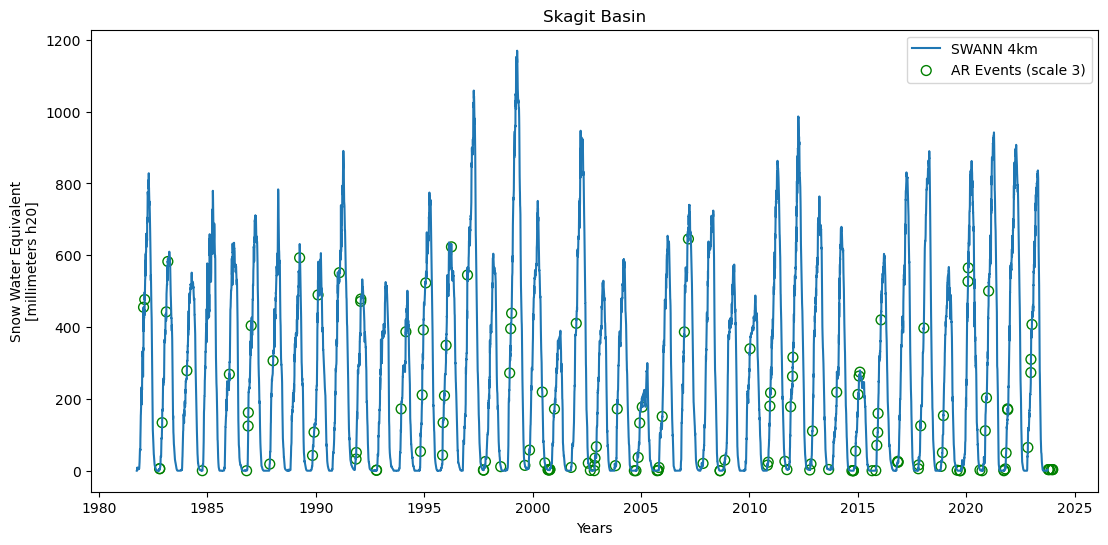

In [49]:
dates_3 = filter_dates(3)
SWE_events_3 = ua_skagit_clipped_mean.sel(time=dates_3, method='nearest')
graph_AR_Events(dates_3, SWE_events_3, 3, 'green')

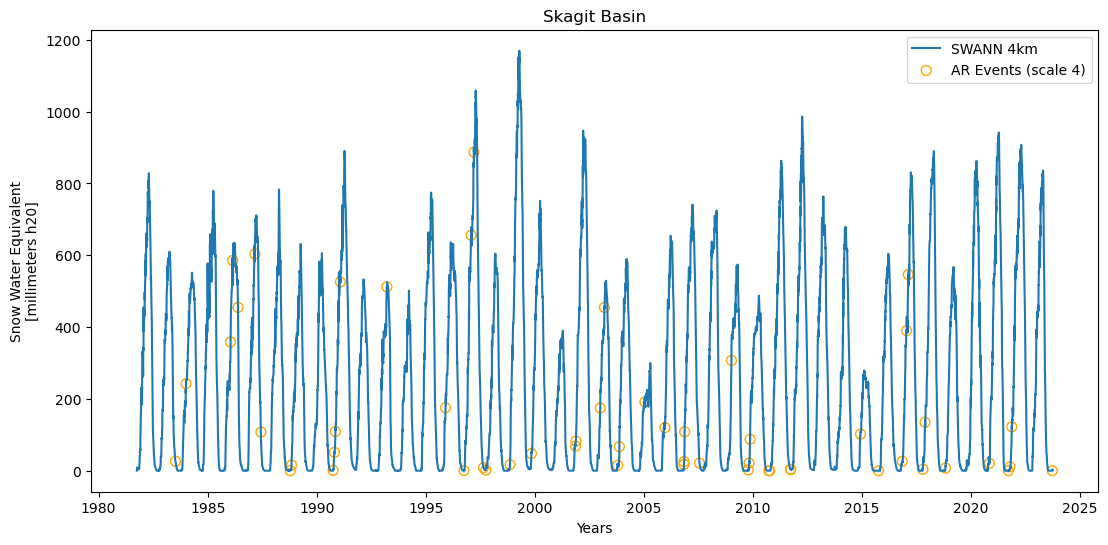

In [48]:
dates_4 = filter_dates(4)
SWE_events_4 = ua_skagit_clipped_mean.sel(time=dates_4, method='nearest')
graph_AR_Events(dates_4, SWE_events_4, 4, 'orange')

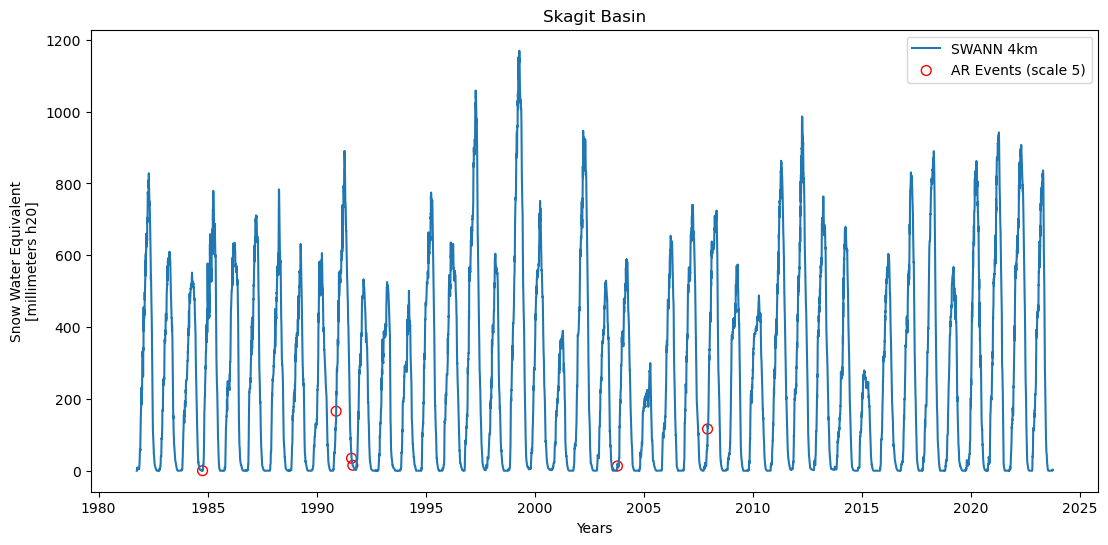

In [47]:
dates_5 = filter_dates(5)
SWE_events_5 = ua_skagit_clipped_mean.sel(time=dates_5, method='nearest')
graph_AR_Events(dates_5, SWE_events_5, 5, 'red')

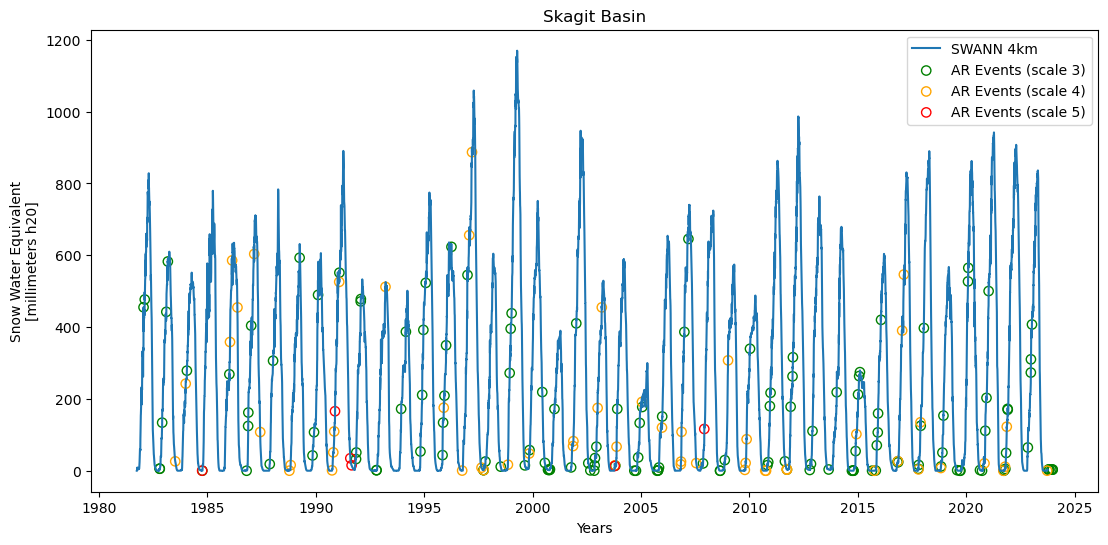

In [50]:
plt.figure(figsize=(13, 6))
ua_skagit_clipped_mean.plot(label='SWANN 4km')

plt.scatter(dates_3, SWE_events_3, facecolors='none', edgecolors='green', s=45, label="AR Events (scale 3)")
plt.scatter(dates_4, SWE_events_4, facecolors='none', edgecolors='orange', s=45, label="AR Events (scale 4)")
plt.scatter(dates_5, SWE_events_5, facecolors='none', edgecolors='red', s=45, label="AR Events (scale 5)")

plt.legend()
plt.xlabel("Years")
plt.title("Skagit Basin")
plt.show()